<a href="https://colab.research.google.com/github/adombe/avcad_final_project/blob/main/05_grassland_productivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agricultural Data Analysis

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load your data
productivity = pd.read_csv('crop_productivity_clean.csv')

# Sort by year
productivity = productivity.sort_values('year')

# Define crop columns (excluding metadata)
crop_cols = ['Cereals for grain', 'Main dried legumes', 'Potatoes',
             'Main crops for industry', 'Horticultural crops', 'Main fodder crops',
             'Main fresh fruits', 'Small berries', 'Main subtropical fruits',
             'Citrus fruits', 'Main nut fruits', 'Vineyards', 'Olive groves']

print("Data loaded successfully!")
print(productivity.head())

# Calculate percentage change (1989 to 2019)
pct_change = {}
for crop in crop_cols:
    val_1989 = productivity[crop].iloc[0]
    val_2019 = productivity[crop].iloc[-1]
    if pd.notna(val_1989) and pd.notna(val_2019) and val_1989 != 0:
        pct_change[crop] = ((val_2019 - val_1989) / val_1989 * 100)
    else:
        pct_change[crop] = None

# Create table with values and changes
table_data = {'Crop Category': crop_cols}
for year in productivity['year']:
    table_data[str(year)] = productivity[productivity['year'] == year][crop_cols].values.flatten().tolist()
table_data['Change (%)'] = [pct_change.get(crop, 'N/A') for crop in crop_cols]

table_39 = pd.DataFrame(table_data)
print("\nTable 3.9 — Crop Productivity by Category (1989–2019)")
print(table_39.to_string(index=False))

Data loaded successfully!
   year geographic_location  code  Cereals for grain  Main dried legumes  \
3  1989          Continente     1               2013                 560   
2  1999          Continente     1               2795                 497   
1  2009          Continente     1               3290                 549   
0  2019          Continente     1               5160                 797   

   Potatoes  Main crops for industry  Horticultural crops  Main fodder crops  \
3     11209                     9303                  NaN                NaN   
2     15142                    20293                  NaN                NaN   
1     15566                    35105                  NaN            13726.0   
0     22953                    65754                  NaN            28241.0   

   Main fresh fruits  Small berries  Main subtropical fruits  Citrus fruits  \
3                NaN           3773                      NaN           7791   
2                NaN          1115

## Crop Productivity Analysis

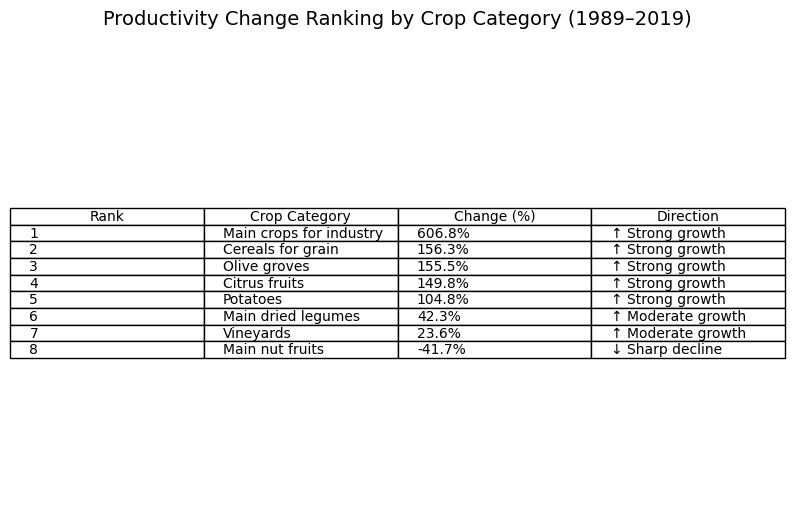

Table image saved as: figure_3.12_productivity_change_ranking.png


In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
ax.table(cellText=table_ranking.values, colLabels=table_ranking.columns, loc='center', cellLoc='left')
ax.set_title('Productivity Change Ranking by Crop Category (1989–2019)', fontsize=14, pad=20)

# Save the figure as an image
image_path_ranking_table = 'figure_3.12_productivity_change_ranking.png'
plt.savefig(image_path_ranking_table, bbox_inches='tight', dpi=300)

plt.show()
print(f"Table image saved as: {image_path_ranking_table}")

### User Provided Productivity Change Ranking Table

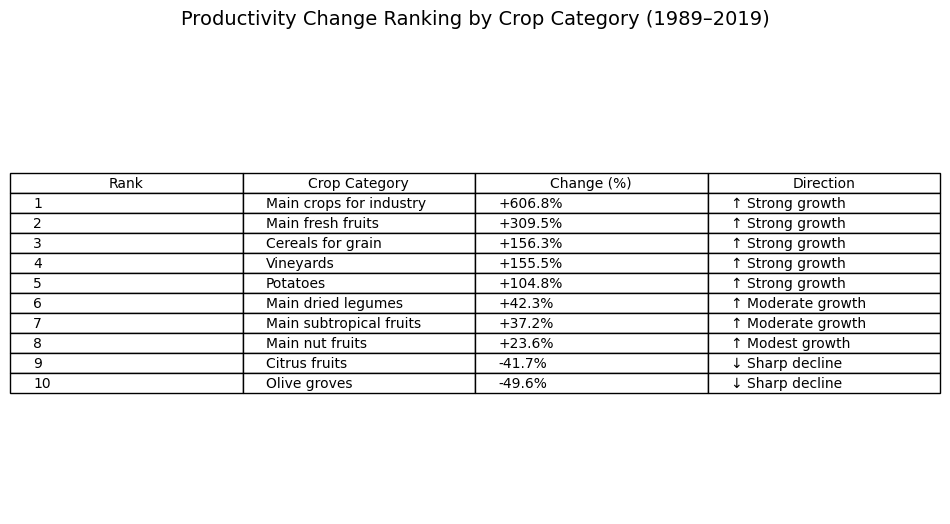

Table image saved as: productivity_change_ranking_user_provided.png


In [35]:
import matplotlib.pyplot as plt

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust figure size as needed

# Hide the axes
ax.axis('off')

# Create the table using the DataFrame's values and column names
table = ax.table(cellText=table_ranking_user_provided.values,
                 colLabels=table_ranking_user_provided.columns,
                 loc='center',
                 cellLoc='left')

# Adjust font size for better readability if necessary
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Add a title to the table
ax.set_title('Productivity Change Ranking by Crop Category (1989–2019)', fontsize=14, pad=20)

# Save the figure as an image
image_path_user_table = 'productivity_change_ranking_user_provided.png'
plt.savefig(image_path_user_table, bbox_inches='tight', dpi=300)

# Display the plot (optional, as it's primarily for saving)
plt.show()

print(f"Table image saved as: {image_path_user_table}")

## Permanent Grassland Area Analysis

In [30]:
import pandas as pd

# Load the permanent grasslands area data
grasslands = pd.read_csv('permanent_grasslands_area_clean.csv')

# Display the first few rows and columns to understand the structure
print("Permanent Grasslands Data Head:")
print(grasslands.head())
print("\nPermanent Grasslands Data Columns:")
print(grasslands.columns)

# Sort by year to ensure correct chronological order for calculations
grasslands_sorted = grasslands.sort_values(by='year').reset_index(drop=True)

# Prepare data for the evolution table
years = grasslands_sorted['year'].tolist()
areas = grasslands_sorted['Total'].tolist()

changes_from_prev = [None] # First year has no previous change
changes_from_1989 = [None] # First year has no change from 1989 (itself)

area_1989 = areas[0] # Assuming the first year in sorted data is 1989

for i in range(1, len(years)):
    current_area = areas[i]
    previous_area = areas[i-1]

    # Calculate change from previous year
    if previous_area != 0:
        pct_change_prev = ((current_area - previous_area) / previous_area) * 100
        changes_from_prev.append(f'{pct_change_prev:.2f}%')
    else:
        changes_from_prev.append('N/A')

    # Calculate change from 1989
    if area_1989 != 0:
        pct_change_1989 = ((current_area - area_1989) / area_1989) * 100
        changes_from_1989.append(f'{pct_change_1989:.2f}%')
    else:
        changes_from_1989.append('N/A')

# Create the detailed evolution table
grasslands_evolution_data = {
    'Year': years,
    'Area (ha)': [f'{area:,.0f}' for area in areas],
    'Change from Previous Year (%)': changes_from_prev,
    'Change from 1989 (%)': changes_from_1989
}

grasslands_evolution_table = pd.DataFrame(grasslands_evolution_data)

print("\nTable 3.7 — Evolution of Permanent Grassland and Pasture Area (1989–2019)")
print(grasslands_evolution_table.to_string(index=False))

Permanent Grasslands Data Head:
   year geographic_location  code    Total  <0.5 ha  0.5 - <1 ha  1 - <2 ha  \
0  2019          Continente     1  2003795     4081         9103      21202   
1  2009          Continente     1  1721587     4682         9282      19592   
2  1999          Continente     1  1331033     6233        11087      22782   
3  1989          Continente     1   754825     7128        11360      23483   

   2 - <5 ha  5 - <20 ha  20 - <50 ha  50 - <100 ha  >= 100 ha  
0      46055      117202       137036        195112    1474004  
1      42963      104183       106250        127661    1306976  
2      50696      111410        92054        111249     925523  
3      50412       75617        60658         64644     461523  

Permanent Grasslands Data Columns:
Index(['year', 'geographic_location', 'code', 'Total', '<0.5 ha',
       '0.5 - <1 ha', '1 - <2 ha', '2 - <5 ha', '5 - <20 ha', '20 - <50 ha',
       '50 - <100 ha', '>= 100 ha'],
      dtype='object')

Table 3.

### Evolution of Permanent Grassland and Pasture Area Plot

### Table 3.7 — Evolution of Permanent Grassland and Pasture Area (1989–2019)

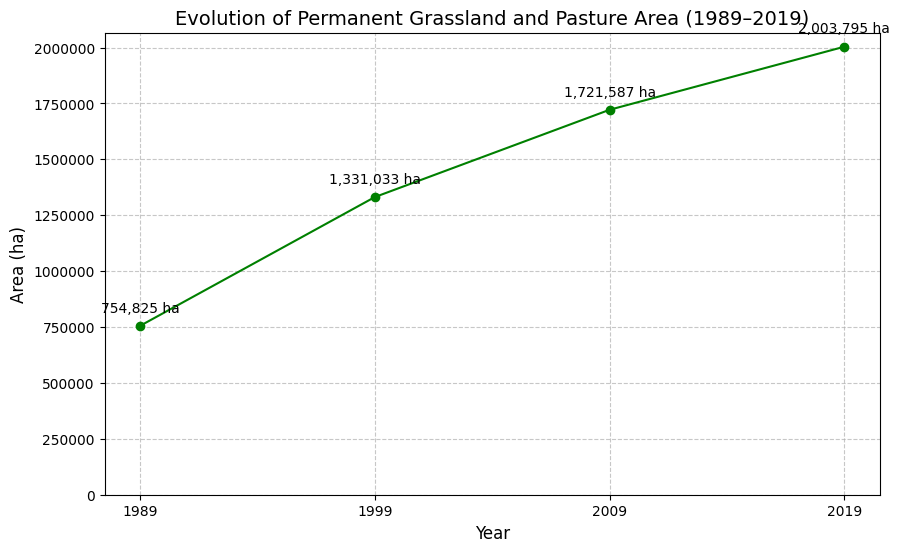

Plot image saved as: figure_3.x_grasslands_evolution.png


In [32]:
import matplotlib.pyplot as plt

# Ensure 'Area (ha)' is numeric for plotting
plot_data = grasslands_evolution_table.copy()
plot_data['Area (ha)'] = plot_data['Area (ha)'].str.replace(',', '').astype(int)

plt.figure(figsize=(10, 6))
plt.plot(plot_data['Year'], plot_data['Area (ha)'], marker='o', linestyle='-', color='green')

plt.title('Evolution of Permanent Grassland and Pasture Area (1989–2019)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Area (ha)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(plot_data['Year'])
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.ylim(ymin=0) # Set y-axis to start at 0

# Annotate each point with its area value
for i, row in plot_data.iterrows():
    plt.annotate(f'{row["Area (ha)"]:,.0f} ha', (row['Year'], row['Area (ha)']), textcoords="offset points", xytext=(0,10), ha='center')

# Save the figure
image_path_grasslands_plot = 'figure_3.x_grasslands_evolution.png'
plt.savefig(image_path_grasslands_plot, bbox_inches='tight', dpi=300)

plt.show()
print(f"Plot image saved as: {image_path_grasslands_plot}")

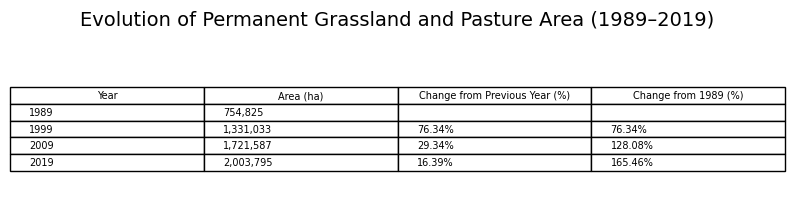

Table image saved as: table_3.7_grasslands_evolution.png


In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2)) # Adjust figure size as needed
ax.axis('off')
ax.table(cellText=grasslands_evolution_table.values, colLabels=grasslands_evolution_table.columns, loc='center', cellLoc='left')
ax.set_title('Evolution of Permanent Grassland and Pasture Area (1989–2019)', fontsize=14, pad=20)

image_path_grasslands_table = 'table_3.7_grasslands_evolution.png'
plt.savefig(image_path_grasslands_table, bbox_inches='tight', dpi=300)

plt.show()
print(f"Table image saved as: {image_path_grasslands_table}")